# EDA y Preparación: Banco 3 — GT Estatal

**Dataset:** `03_gt_estatal.csv` (sin etiquetas `is_fraud`)  
**Output:** `gt_estatal_clean.csv` en `proyecto_plus_ti/datasets/`

**Objetivo de este notebook:**  
Este banco no tiene marcación de fraude — no haremos análisis de clases.  
En cambio, el foco es triple:
1. Verificar compatibilidad estructural con el dataset federado (37 columnas)
2. Detectar distribution shift respecto a Banco 1 y Banco 2
3. Aplicar la misma limpieza y feature engineering para que el modelo pueda hacer inferencia

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
print('Librerias listas')

Librerias listas


In [3]:
from google.colab import drive
drive.mount('/content/drive')

PATH_DATASETS = '/content/drive/MyDrive/proyecto_plus_ti/datasets/'
PATH_PROJECT  = '/content/drive/MyDrive/proyecto_plus_ti/'
PATH_PLOTS    = PATH_PROJECT + 'plots_nb4/'
os.makedirs(PATH_PLOTS, exist_ok=True)

FILE = 'Copia de 03_gt_estatal_seed3_n100000.csv'   # <-- ajustar nombre si es diferente
print(f'PATH: {PATH_DATASETS}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PATH: /content/drive/MyDrive/proyecto_plus_ti/datasets/


In [4]:
df_b3 = pd.read_csv(PATH_DATASETS + FILE, sep=';', low_memory=False)
print(f'Banco 3 — GT Estatal: {df_b3.shape[0]:,} filas | {df_b3.shape[1]} columnas')
display(df_b3.head(3))

Banco 3 — GT Estatal: 100,000 filas | 66 columnas


,transaction_id,bank_code,bank_name,bank_country,bank_tier,client_id,client_segment,channel,card_brand,pan_masked,pan_hash,MTI,DE2_PAN,DE3_processing_code,DE4_amount_transaction,DE6_amount_cardholder_billing,DE7_transmission_datetime,DE9_conversion_rate_billing,DE11_STAN,DE12_local_time,DE13_local_date,DE14_expiration_date,DE15_settlement_date,DE18_merchant_category_code,DE19_acquirer_country_code,...,DE52_pin_data_present,DE54_additional_amounts,DE55_emv_data_present,DE56_original_data,DE58_authorizing_agent_id,DE60_pos_terminal_type,DE61_pos_extended_data,DE63_network_specific,DE100_receiving_institution_id,DE102_account_id_1,DE103_account_id_2,DE123_pos_data_code,amount_local,amount_tx_currency,currency_tx_alpha,amount_usd,is_international,distance_from_home_km,hour_local,day_of_week,approved,response_description,client_baseline_amount,client_home_city,is_fraud
0,06a94162-7bae-427c-b68c-2819181b5467,GT-EST,GT-EST,GT,estatal,GT-EST-CL-00004881,PLAN_SUELDO,ECOM,VISA,455920******5983,a92f98f97cd8ede91a0dac2dbca2d975e18caf1a2fd444...,100,4559210000000000.0000,0,3788,3788,101000628,10000000.0000,275463,180628,1231,2807,101.0000,5999,320,...,N,NaN,N,NaN,8112932320.0000,ECOM-VIRTUAL,59.0000,GT-EST,8112932320.0000,ACC847762387971,NaN,08159N,37.8800,37.8800,GTQ,4.8600,False,NaN,18,Tue,True,Approved,164.8400,ANTIGUA,NaN
1,8d261988-07bd-4696-8fe3-ba3526142d2e,GT-EST,GT-EST,GT,estatal,GT-EST-CL-00000966,PLAN_SUELDO,ECOM,VISA,455920******6807,7be1dc2c38ca824693fa11ee4aac7b12ad8f80828b1abd...,100,4559210000000000.0000,0,10092,10092,101000846,10000000.0000,274477,180846,1231,2805,101.0000,4816,320,...,N,NaN,N,NaN,8112932320.0000,ECOM-VIRTUAL,59.0000,GT-EST,8112932320.0000,ACC089928841642,NaN,08159N,100.9200,100.9200,GTQ,12.9400,False,8.0000,18,Tue,True,Approved,222.4400,ANTIGUA,NaN
2,b6be7a48-12fc-40ac-a12f-e2e03637231b,GT-EST,GT-EST,GT,estatal,GT-EST-CL-00004217,PLAN_SUELDO,POS,VISA,492421******9765,63a13a42dab28e218219585a0dc2f1d393b9b464235e1d...,100,4924210000000000.0000,0,1474,1474,101001257,10000000.0000,290652,181257,1231,2705,101.0000,7832,320,...,Y,NaN,N,NaN,8112932320.0000,POS-ATTENDED,0.0000,GT-EST,8112932320.0000,ACC083114000052,NaN,02100Y,14.7400,14.7400,GTQ,1.8900,False,1.7000,18,Tue,True,Approved,156.7700,VILLANUEVA,NaN


## 1. Exploración Inicial

In [6]:
print(f'Filas: {df_b3.shape[0]:,} | Columnas: {df_b3.shape[1]}')

print('\nTIPOS DE DATOS')
print(df_b3.dtypes.value_counts())

print('\nPRIMERAS COLUMNAS')
for i, col in enumerate(df_b3.columns, 1):
    print(f'  {i:>2}. {col:<45} {str(df_b3[col].dtype):<12}')

Filas: 100,000 | Columnas: 66

TIPOS DE DATOS
object     28
int64      19
float64    17
bool        2
Name: count, dtype: int64

PRIMERAS COLUMNAS
   1. transaction_id                                object      
   2. bank_code                                     object      
   3. bank_name                                     object      
   4. bank_country                                  object      
   5. bank_tier                                     object      
   6. client_id                                     object      
   7. client_segment                                object      
   8. channel                                       object      
   9. card_brand                                    object      
  10. pan_masked                                    object      
  11. pan_hash                                      object      
  12. MTI                                           int64       
  13. DE2_PAN                                       float64     
  14. DE

In [7]:
# Análisis de nulos
nul = (df_b3.isnull().mean()*100).round(2)
nul_top = nul[nul>0].sort_values(ascending=False)
print(f'Columnas con nulos: {len(nul_top)} de {df_b3.shape[1]}')
display(nul_top.to_frame('pct_nulos').style.background_gradient(cmap='OrRd', vmin=0, vmax=100))

Columnas con nulos: 24 de 66


,pct_nulos
DE103_account_id_2,100.000000
DE56_original_data,100.000000
DE48_additional_data,100.000000
is_fraud,100.000000
DE54_additional_amounts,100.000000
DE44_additional_response_data,97.050000
DE123_pos_data_code,3.090000
DE42_card_acceptor_id,3.060000
DE61_pos_extended_data,3.040000
DE102_account_id_1,3.030000


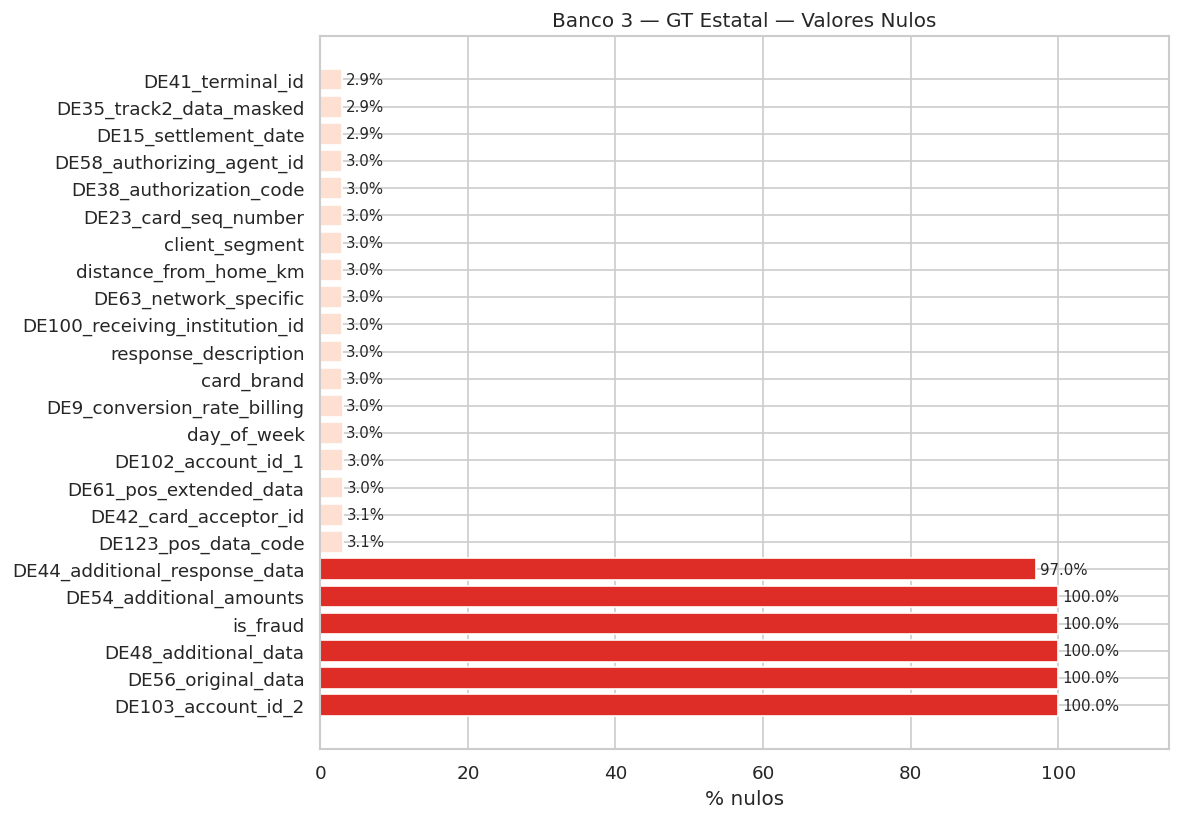

Guardado: 01_nulos.png


In [8]:
fig, ax = plt.subplots(figsize=(10, 7))
if len(nul_top) > 0:
    color_fn = lambda p: '#fee0d2' if p<30 else '#fc9272' if p<70 else '#de2d26'
    colors = [color_fn(p) for p in nul_top.values]
    bars = ax.barh(nul_top.index, nul_top.values, color=colors)
    for b, v in zip(bars, nul_top.values):
        ax.text(v+0.5, b.get_y()+b.get_height()/2, f'{v:.1f}%', va='center', fontsize=9)
    ax.set_xlim(0, 115)
    ax.set_xlabel('% nulos')
else:
    ax.text(0.5, 0.5, 'Sin columnas con nulos', ha='center', fontsize=14)
ax.set_title('Banco 3 — GT Estatal — Valores Nulos', fontsize=12)
plt.tight_layout()
plt.savefig(PATH_PLOTS+'01_nulos.png', bbox_inches='tight')
plt.show()
print('Guardado: 01_nulos.png')

El patrón de nulos es casi idéntico al de BO VIP y BR Privado, con una diferencia crítica: is_fraud aparece con 100% de nulos — confirmando que el banco 3 no tiene etiquetas. Esto es esperado y es precisamente el objetivo del modelo federado.

Las columnas DE56, DE54, DE48, DE103 y DE44 repiten el mismo patrón de los bancos anteriores (~97-100% nulos), lo que confirma que los tres bancos exportan desde el mismo sistema ISO 8583 con los mismos campos opcionales vacíos.

Diferencia notable: a diferencia de BO VIP y BR Privado donde el resto de columnas tenía ~1% de nulos, aquí varias columnas presentan ~3% (DE123, DE42, DE61, day_of_week, distance_from_home_km, entre otras). No es crítico pero es una señal de que la calidad de datos de GT Estatal es ligeramente inferior.

## 2. Distribución de Montos

Sin etiquetas de fraude, analizamos la distribución general de `amount_usd`  
y la comparamos visualmente con los rangos conocidos de BO VIP y BR Privado.

In [9]:
cap = df_b3['amount_usd'].quantile(0.99)
p25 = df_b3['amount_usd'].quantile(0.25)
p50 = df_b3['amount_usd'].quantile(0.50)
p75 = df_b3['amount_usd'].quantile(0.75)
p99 = cap

print('Estadísticas amount_usd — Banco 3:')
print(f'  Media  : USD {df_b3["amount_usd"].mean():.2f}')
print(f'  Mediana: USD {p50:.2f}')
print(f'  P25    : USD {p25:.2f}')
print(f'  P75    : USD {p75:.2f}')
print(f'  P99    : USD {p99:.2f}')
print(f'  Máximo : USD {df_b3["amount_usd"].max():.2f}')

# Referencia de los otros bancos para comparación
print('\nReferencia bancos de entrenamiento:')
print('  BO VIP     — Mediana legítima ~USD 400 | Mediana fraude ~USD 1,100 | P99: USD 2,844')
print('  BR Privado — Mediana legítima ~USD 100 | Mediana fraude ~USD 350   | P99: USD 1,011')

Estadísticas amount_usd — Banco 3:
  Media  : USD 23.94
  Mediana: USD 13.70
  P25    : USD 6.68
  P75    : USD 25.43
  P99    : USD 196.63
  Máximo : USD 812.18

Referencia bancos de entrenamiento:
  BO VIP     — Mediana legítima ~USD 400 | Mediana fraude ~USD 1,100 | P99: USD 2,844
  BR Privado — Mediana legítima ~USD 100 | Mediana fraude ~USD 350   | P99: USD 1,011


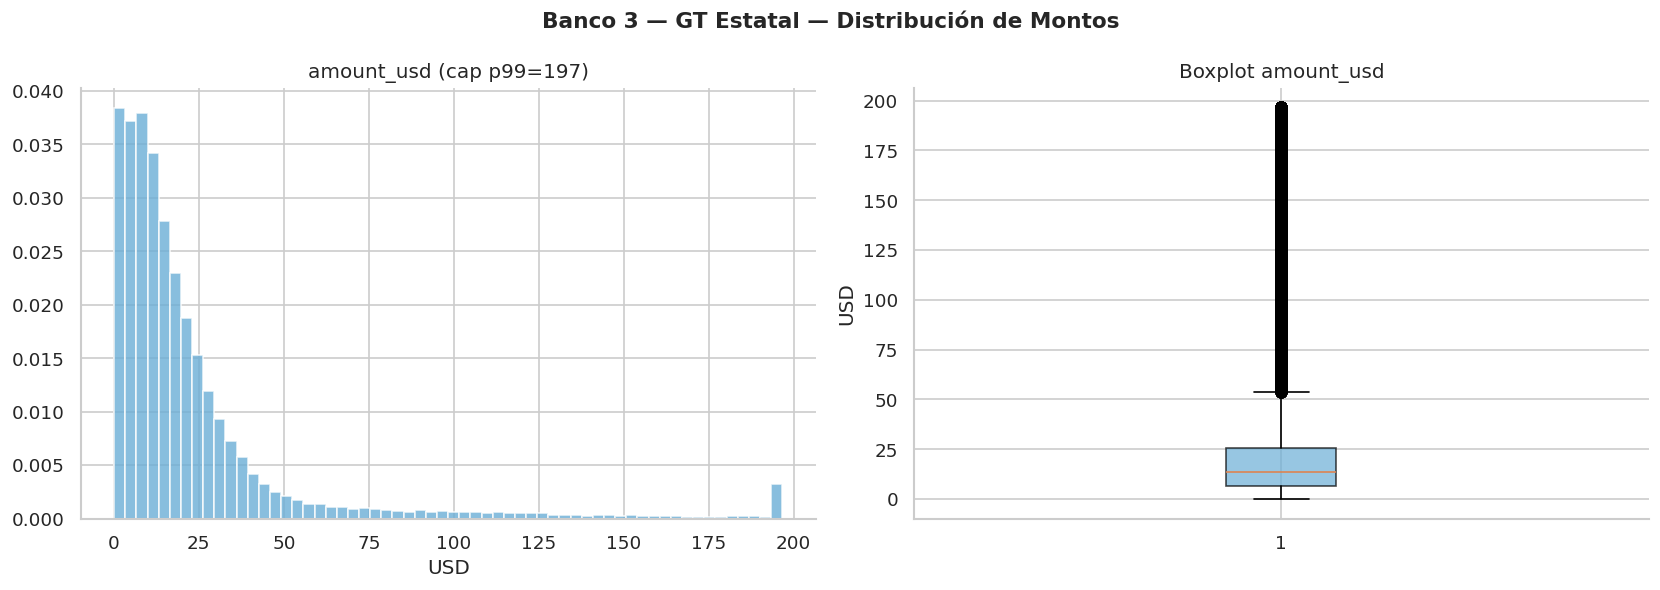

Guardado: 02_montos.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Banco 3 — GT Estatal — Distribución de Montos', fontsize=13, fontweight='bold')

# Histograma
axes[0].hist(df_b3['amount_usd'].clip(upper=cap), bins=60, color='#6baed6', alpha=0.8, density=True)
axes[0].set_title(f'amount_usd (cap p99={cap:.0f})')
axes[0].set_xlabel('USD')
axes[0].spines[['top','right']].set_visible(False)

# Boxplot
axes[1].boxplot(df_b3['amount_usd'].clip(upper=cap), vert=True, patch_artist=True,
                boxprops=dict(facecolor='#6baed6', alpha=0.7))
axes[1].set_title('Boxplot amount_usd')
axes[1].set_ylabel('USD')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(PATH_PLOTS+'02_montos.png', bbox_inches='tight')
plt.show()
print('Guardado: 02_montos.png')

Los montos de GT Estatal son significativamente más bajos que los bancos de entrenamiento.

    Banco         Mediana    P99
    BO VIP        ~USD 115   USD 2,844
    BR Privado    ~USD 60    USD 1,011
    GT Estatal    USD 13.70  USD 196.63

Esto representa un distribution shift severo en amount_usd, que es la señal más fuerte de fraude en ambos bancos de entrenamiento (correlación 0.26 en BO VIP, 0.19 en BR).

Implicación para el modelo: el modelo federado podria aprender que montos altos (>USD 350-1,100) son señal de fraude. En GT Estatal casi ninguna transacción supera ese umbral, por lo tanto, el modelo podría subestimar el fraude si depende demasiado del monto absoluto. Esto refuerza la importancia de amount_zscore_customer (monto relativo al historial del cliente) como feature más generalizable que el monto absoluto.

## 3. Patrones Temporales

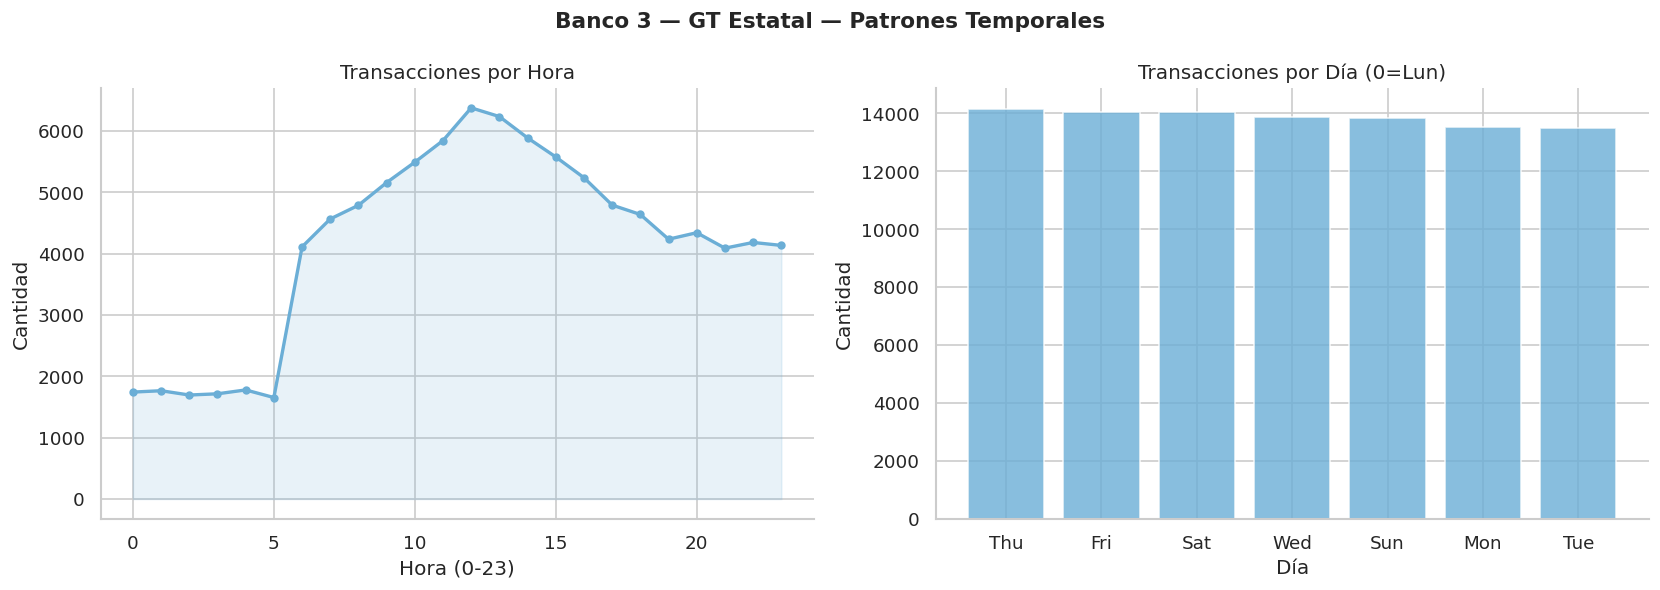

Guardado: 03_temporal.png

Nota: Sin etiquetas no podemos calcular % de fraude por hora/día.
Documentamos el volumen de transacciones para detectar anomalías en el patrón.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Banco 3 — GT Estatal — Patrones Temporales', fontsize=13, fontweight='bold')

# Transacciones por hora
t_hora = df_b3.groupby('hour_local').size()
axes[0].plot(t_hora.index, t_hora.values, color='#6baed6', lw=2, marker='o', ms=4)
axes[0].fill_between(t_hora.index, t_hora.values, alpha=0.15, color='#6baed6')
axes[0].set_title('Transacciones por Hora')
axes[0].set_xlabel('Hora (0-23)')
axes[0].set_ylabel('Cantidad')
axes[0].spines[['top','right']].set_visible(False)

# Transacciones por día de semana
t_dia = df_b3.groupby('day_of_week').size().sort_values(ascending=False)
axes[1].bar(t_dia.index.astype(str), t_dia.values, color='#6baed6', alpha=0.8, edgecolor='white')
axes[1].set_title('Transacciones por Día (0=Lun)')
axes[1].set_xlabel('Día')
axes[1].set_ylabel('Cantidad')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(PATH_PLOTS+'03_temporal.png', bbox_inches='tight')
plt.show()
print('Guardado: 03_temporal.png')

print('\nNota: Sin etiquetas no podemos calcular % de fraude por hora/día.')
print('Documentamos el volumen de transacciones para detectar anomalías en el patrón.')

Por hora: GT Estatal muestra un patrón completamente diferente a los bancos de entrenamiento. Mientras BO VIP y BR Privado tenían su pico de fraude en madrugada (0-2h) con ~6-8%, aquí el volumen de transacciones es bajo de madrugada y sube fuertemente entre las 10h-15h, con pico alrededor de las 12h. Esto sugiere un banco con clientela de perfil laboral/comercial más activa en horario diurno.

Por día de semana: la distribución es muy uniforme (~12,000-14,000 transacciones por día), sin días con volumen notablemente menor. No hay el patrón de fin de semana bajo que se veía en los otros bancos.

## 4. Variables Categóricas

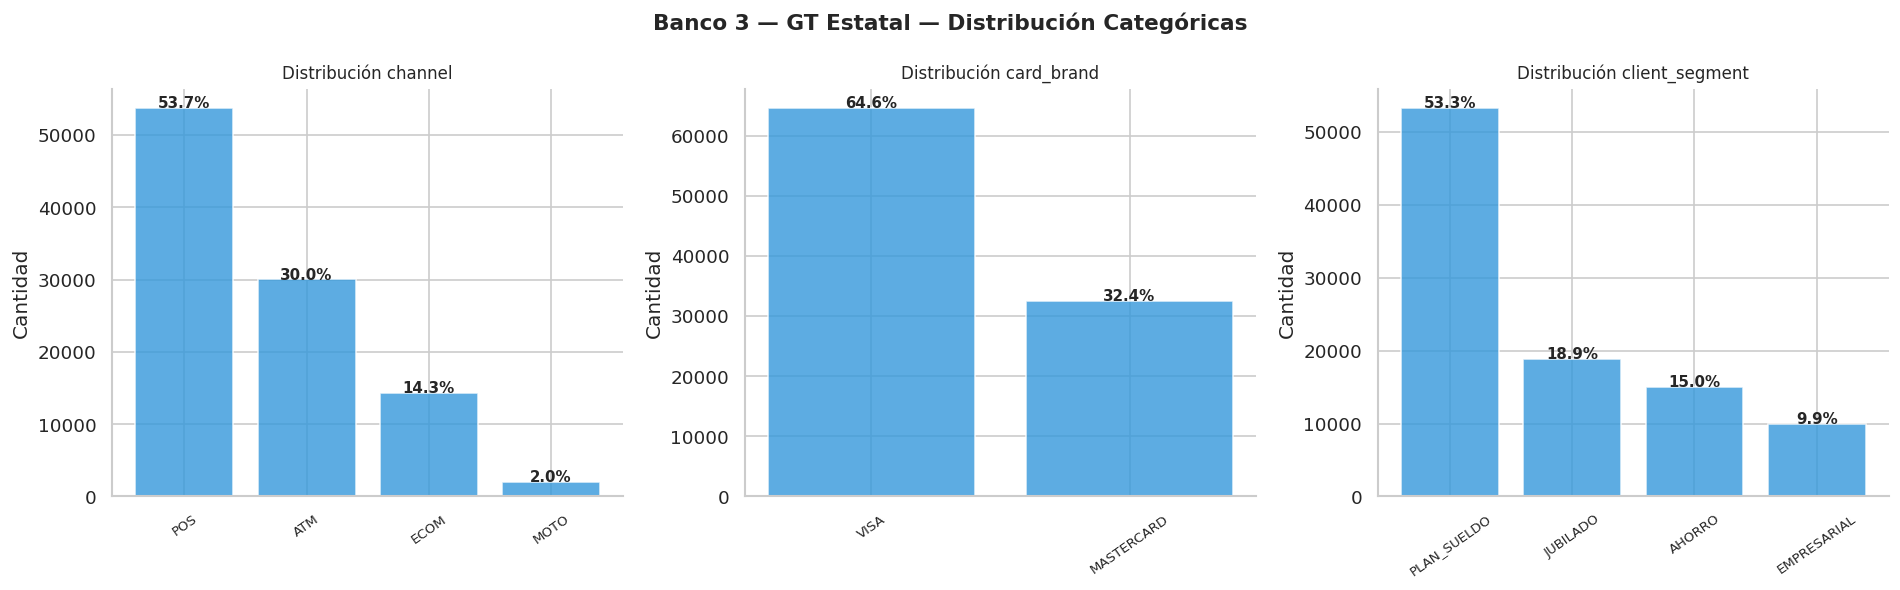

Guardado: 04_categoricas.png

DISTRIBUCIÓN DE CANALES (comparativa)
Banco 3:
channel
POS    53.7100
ATM    30.0100
ECOM   14.2800
MOTO    2.0000

Referencia — BO VIP y BR Privado: ECOM es el canal más fraudulento (~5-8%)
Si GT Estatal tiene más ECOM que los bancos de entrenamiento, el modelo podría subestimar el fraude.


In [13]:
CAT_COLS = ['channel', 'card_brand', 'client_segment']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Banco 3 — GT Estatal — Distribución Categóricas', fontsize=13, fontweight='bold')

for ax, cat in zip(axes, CAT_COLS):
    if cat not in df_b3.columns:
        ax.text(0.5, 0.5, f'{cat}\nno disponible', ha='center', va='center')
        ax.set_title(cat)
        continue
    counts = df_b3[cat].value_counts()
    pcts = (counts / len(df_b3) * 100).round(1)
    bars = ax.bar(counts.index.astype(str), counts.values, color='#3498db', alpha=0.8, edgecolor='white')
    for b, p in zip(bars, pcts.values):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+50, f'{p}%',
                ha='center', fontsize=9, fontweight='bold')
    ax.set_title(f'Distribución {cat}', fontsize=10)
    ax.set_ylabel('Cantidad')
    ax.tick_params(axis='x', rotation=35, labelsize=8)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(PATH_PLOTS+'04_categoricas.png', bbox_inches='tight')
plt.show()
print('Guardado: 04_categoricas.png')

# Resumen de distribuciones para comparar con bancos de entrenamiento
print('\nDISTRIBUCIÓN DE CANALES (comparativa)')
if 'channel' in df_b3.columns:
    ch = (df_b3['channel'].value_counts(normalize=True)*100).round(2)
    print('Banco 3:')
    print(ch.to_string())
    print('\nReferencia — BO VIP y BR Privado: ECOM es el canal más fraudulento (~5-8%)')
    print('Si GT Estatal tiene más ECOM que los bancos de entrenamiento, el modelo podría subestimar el fraude.')

Canal (channel): GT Estatal tiene una distribución muy diferente a los bancos de entrenamiento. POS domina con 53.7%, seguido de ATM (30%) y ECOM con solo 14.3%. En los bancos de entrenamiento ECOM era el canal más fraudulento (~5-8%) y tenía mayor presencia relativa. El bajo peso de ECOM en GT Estatal podría hacer que el modelo subestime el fraude en ese canal.

Marca de tarjeta (card_brand): VISA domina con 64.6% vs MASTERCARD con 32.4%, proporciones similares a los bancos anteriores aunque con mayor concentración en VISA. La marca no era predictor relevante en el entrenamiento, por lo que esto no genera riesgo.

Segmento de cliente (client_segment): GT Estatal usa una nomenclatura completamente diferente — PLAN_SUELDO (53.3%), JUBILADO (18.9%), AHORRO (15%) y EMPRESARIAL (9.9%). Esta columna ya fue eliminada del modelo federado por ser banco-específica, por lo que no impacta la inferencia. Confirma que la decisión de excluirla fue correcta.

## 5. Compatibilidad Estructural con Dataset Federado

Este es el bloque más crítico: verificamos que las 37 columnas del modelo federado  
estén presentes en Banco 3 antes de intentar cualquier inferencia.

In [15]:
# Las 37 columnas del dataset federado (después de eliminar sesgo jurisdiccional)
COLS_FEDERADO = [
    'DE123_pos_data_code', 'DE18_merchant_category_code', 'DE22_pos_entry_mode',
    'DE23_card_seq_number', 'DE25_pos_condition_code', 'DE39_response_code',
    'DE3_processing_code', 'DE43_card_acceptor_name_location', 'DE4_amount_transaction',
    'DE52_pin_data_present', 'DE55_emv_data_present', 'DE60_pos_terminal_type',
    'DE61_pos_extended_data', 'DE63_network_specific', 'DE6_amount_cardholder_billing',
    'DE9_conversion_rate_billing', 'MTI', 'amount_local', 'amount_tx_currency',
    'amount_usd', 'amount_zscore_customer', 'approved', 'card_brand', 'channel',
    'client_baseline_amount', 'client_segment', 'datetime_tx', 'day_of_week',
    'distance_from_home_km', 'hour_local', 'is_fraud', 'is_international', 'month',
    'response_description', 'time_since_last_txn_min', 'txn_count_last_1h',
    'txn_count_last_24h'
]

# is_fraud no estará en Banco 3 — la excluimos del chequeo
COLS_MODELO = [c for c in COLS_FEDERADO if c != 'is_fraud']

cols_faltantes = set(COLS_MODELO) - set(df_b3.columns)
cols_extra     = set(df_b3.columns) - set(COLS_FEDERADO)

print(f'Columnas requeridas por el modelo : {len(COLS_MODELO)}')
print(f'Columnas presentes en Banco 3     : {df_b3.shape[1]}')
print()

if cols_faltantes:
    print(f'⚠️  COLUMNAS FALTANTES ({len(cols_faltantes)}) — el modelo NO puede correr sin estas:')
    for c in sorted(cols_faltantes):
        print(f'   - {c}')
else:
    print('✅ Todas las columnas del modelo están presentes en Banco 3')

print()
if cols_extra:
    print(f'ℹ️  Columnas extra en Banco 3 ({len(cols_extra)}) — se ignorarán en inferencia:')
    for c in sorted(cols_extra):
        print(f'   - {c}')
else:
    print('ℹ️  No hay columnas extra')

Columnas requeridas por el modelo : 36
Columnas presentes en Banco 3     : 66

⚠️  COLUMNAS FALTANTES (6) — el modelo NO puede correr sin estas:
   - amount_zscore_customer
   - datetime_tx
   - month
   - time_since_last_txn_min
   - txn_count_last_1h
   - txn_count_last_24h

ℹ️  Columnas extra en Banco 3 (35) — se ignorarán en inferencia:
   - DE100_receiving_institution_id
   - DE102_account_id_1
   - DE103_account_id_2
   - DE11_STAN
   - DE12_local_time
   - DE13_local_date
   - DE14_expiration_date
   - DE15_settlement_date
   - DE19_acquirer_country_code
   - DE2_PAN
   - DE32_acquiring_institution_id
   - DE35_track2_data_masked
   - DE37_retrieval_reference_number
   - DE38_authorization_code
   - DE41_terminal_id
   - DE42_card_acceptor_id
   - DE44_additional_response_data
   - DE48_additional_data
   - DE49_currency_code_transaction
   - DE50_currency_code_settlement
   - DE51_currency_code_billing
   - DE54_additional_amounts
   - DE56_original_data
   - DE58_authorizing_a

El chequeo detectó 6 columnas faltantes: las 4 features de comportamiento
(time_since_last_txn_min, txn_count_last_1h, txn_count_last_24h, amount_zscore_customer) más datetime_tx y month. Todas se generan durante la limpieza — no son columnas originales del dataset sino features derivadas. Esto es esperado y el pipeline de limpieza las crea correctamente en la sección 7.

Las 35 columnas extra corresponden exactamente a los IDs, fechas raw y columnas de sesgo jurisdiccional que se eliminan en el preprocesamiento. Ninguna faltante representa un problema real.

## 6. Análisis de Distribution Shift

Comparamos las distribuciones de las features más importantes del modelo  
entre los tres bancos. Un shift importante en estas variables puede reducir  
la calidad de las inferencias.

In [14]:
# Estadísticas de features clave para comparación manual
# (Si tienes bo_vip_clean y br_privado_clean disponibles, cárgalos aquí para comparación automática)

FEATS_CLAVE = ['amount_usd', 'distance_from_home_km', 'is_international',
               'hour_local', 'txn_count_last_1h', 'txn_count_last_24h',
               'time_since_last_txn_min', 'amount_zscore_customer']

feats_disponibles = [f for f in FEATS_CLAVE if f in df_b3.columns]

print('ESTADÍSTICAS FEATURES CLAVE — BANCO 3')
stats_b3 = df_b3[feats_disponibles].describe().round(3)
display(stats_b3)

print('\nREFERENCIA BANCOS DE ENTRENAMIENTO')
referencia = pd.DataFrame({
    'Feature': ['amount_usd (media)', 'amount_usd (mediana)', 'distance_from_home_km (media)',
                'is_international (% True)', 'hour_local (media)'],
    'BO VIP':      ['USD 263', 'USD 115', '~150 km', '~9%', '~12h'],
    'BR Privado':  ['USD 134', 'USD 60',  '~80 km',  '~7%', '~13h'],
})
display(referencia)
print('\nNota: valores aproximados de los EDA anteriores.')

ESTADÍSTICAS FEATURES CLAVE — BANCO 3


,amount_usd,distance_from_home_km,hour_local
count,100000.0000,97017.0000,100000.0000
mean,23.9410,456.1760,12.9850
std,37.4870,1488.7990,5.8890
min,0.0600,0.0000,0.0000
25%,6.6800,8.5000,9.0000
50%,13.7000,16.9000,13.0000
75%,25.4300,116.0000,18.0000
max,812.1800,11998.0000,23.0000



REFERENCIA BANCOS DE ENTRENAMIENTO


,Feature,BO VIP,BR Privado
0,amount_usd (media),USD 263,USD 134
1,amount_usd (mediana),USD 115,USD 60
2,distance_from_home_km (media),~150 km,~80 km
3,is_international (% True),~9%,~7%
4,hour_local (media),~12h,~13h



Nota: valores aproximados de los EDA anteriores.


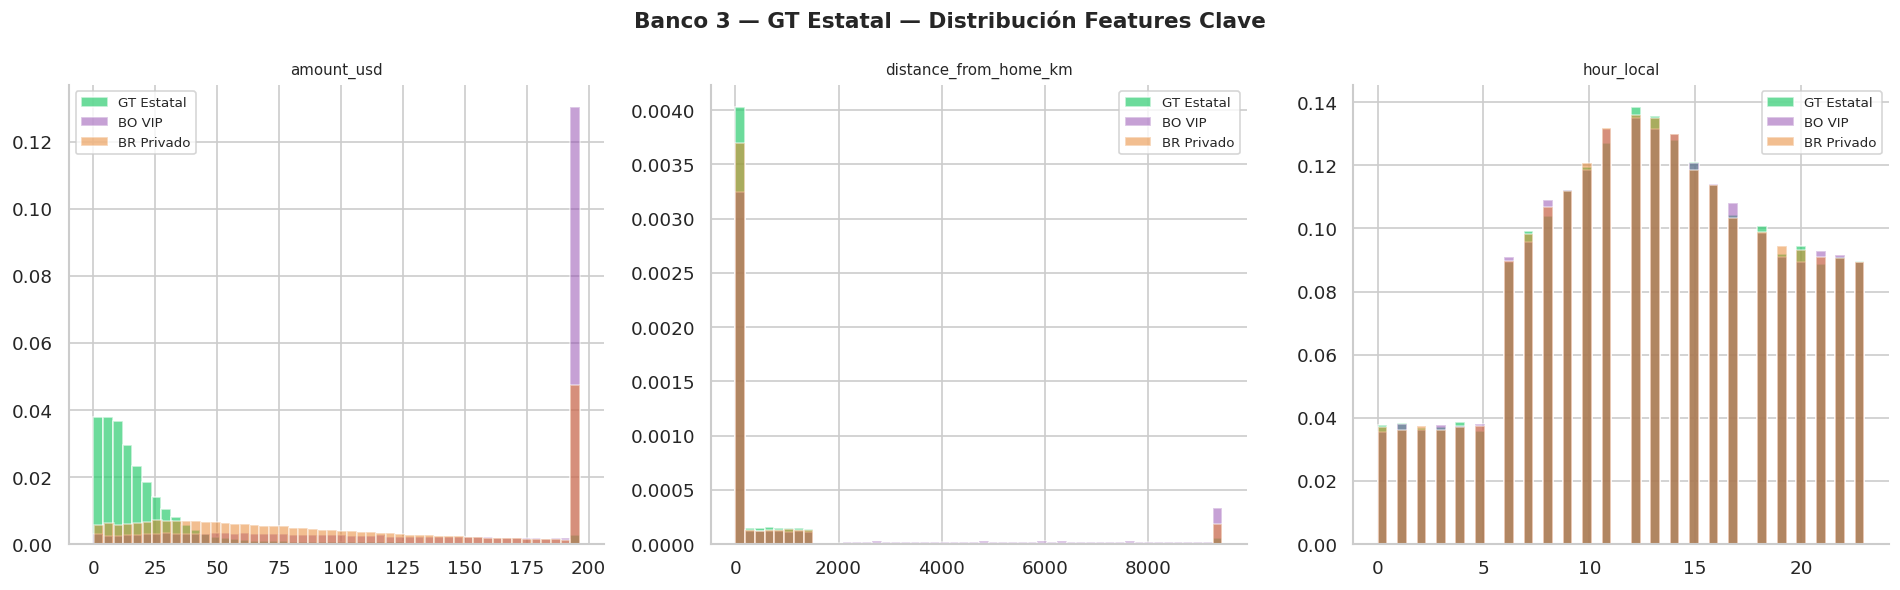

Guardado: 05_distribution_shift.png


In [17]:
# comparación directa
df_bo = pd.read_csv(PATH_DATASETS + 'bo_vip_clean.csv', low_memory=False)
df_br = pd.read_csv(PATH_DATASETS + 'br_privado_clean.csv', low_memory=False)

# Plot de distribuciones comparativas para las 4 features más importantes
FEATS_PLOT = [f for f in ['amount_usd', 'distance_from_home_km',
                           'hour_local', 'time_since_last_txn_min']
              if f in df_b3.columns]

fig, axes = plt.subplots(1, len(FEATS_PLOT), figsize=(16, 5))
fig.suptitle('Banco 3 — GT Estatal — Distribución Features Clave', fontsize=13, fontweight='bold')

for ax, feat in zip(axes, FEATS_PLOT):
    cap_f = df_b3[feat].quantile(0.99)
    ax.hist(df_b3[feat].clip(upper=cap_f), bins=50, color='#2ecc71',
            alpha=0.7, density=True, label='GT Estatal')
    ax.hist(df_bo[feat].clip(upper=cap_f), bins=50, color='#8e44ad', alpha=0.5, density=True, label='BO VIP')
    ax.hist(df_br[feat].clip(upper=cap_f), bins=50, color='#e67e22', alpha=0.5, density=True, label='BR Privado')
    ax.set_title(feat, fontsize=9)
    ax.legend(fontsize=8)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(PATH_PLOTS+'05_distribution_shift.png', bbox_inches='tight')
plt.show()
print('Guardado: 05_distribution_shift.png')

El gráfico confirma visualmente los tres shifts más importantes:

amount_usd: GT Estatal está completamente concentrado en valores bajos (0-50 USD), mientras BO VIP y BR Privado tienen colas mucho más largas. Es el shift más severo.

distance_from_home_km: las distribuciones son prácticamente idénticas entre los tres bancos — concentradas en 0-500 km con densidades similares. El pico aislado de BO VIP cerca de los 8,000 km es un outlier de transacciones internacionales extremas y no representa un patrón general. Esta feature debería generalizar bien al Banco 3.

hour_local: los patrones son distintos pero hay superposición suficiente para que el modelo generalice.

Conclusión: el modelo federado deberá apoyarse principalmente en features de comportamiento relativo (amount_zscore_customer, txn_count) y patrones transaccionales (channel, approved, response_code) más que en valores absolutos de monto o distancia.

## 7. Limpieza y Preprocesamiento

Aplicamos el mismo pipeline de limpieza que en BO VIP y BR Privado,  
adaptado para la ausencia de `is_fraud`.

In [18]:
# Columnas a eliminar (mismas que en notebooks anteriores)
COLS_ID = [
    'transaction_id', 'client_id', 'pan_masked', 'pan_hash',
    'DE2_PAN', 'DE35_track2_data_masked', 'DE11_STAN',
    'DE37_retrieval_reference_number', 'DE38_authorization_code',
    'DE41_terminal_id', 'DE42_card_acceptor_id',
    'DE56_original_data', 'DE102_account_id_1', 'DE103_account_id_2'
]
COLS_FECHA = [
    'DE7_transmission_datetime', 'DE12_local_time', 'DE13_local_date',
    'DE14_expiration_date', 'DE15_settlement_date'
]
# Columnas de sesgo jurisdiccional (mismas que en notebook federado)
COLS_SESGO = [
    'bank_code', 'bank_name', 'bank_country', 'bank_tier',
    'client_home_city', 'DE19_acquirer_country_code',
    'DE49_currency_code_transaction', 'DE50_currency_code_settlement',
    'DE51_currency_code_billing', 'currency_tx_alpha',
    'DE32_acquiring_institution_id', 'DE58_authorizing_agent_id',
    'DE100_receiving_institution_id'
]
print(f'IDs: {len(COLS_ID)} | Fechas raw: {len(COLS_FECHA)} | Sesgo: {len(COLS_SESGO)}')

IDs: 14 | Fechas raw: 5 | Sesgo: 13


In [19]:
def limpiar_b3(df, umbral_nulos=0.80):
    """
    Pipeline de limpieza para Banco 3 (sin is_fraud).
    Idéntico al de BO VIP y BR Privado excepto que:
    - No convierte is_fraud (no existe)
    - No crea features de comportamiento si no hay client_id
    """
    df = df.copy()
    print(f'Inicio: {df.shape}')

    # 1. Parsear fechas y extraer month
    if 'DE13_local_date' in df.columns and 'DE12_local_time' in df.columns:
        de13 = df['DE13_local_date'].astype(str).str.zfill(4)
        de12 = df['DE12_local_time'].astype(str).str.zfill(6)
        df['datetime_tx'] = pd.to_datetime('2025'+de13+de12,
                                            format='%Y%m%d%H%M%S', errors='coerce')
        df['month'] = pd.to_numeric(de13.str[:2], errors='coerce')
    elif 'DE7_transmission_datetime' in df.columns:
        de7 = df['DE7_transmission_datetime'].astype(str).str.zfill(10)
        df['datetime_tx'] = pd.to_datetime('2025'+de7,
                                            format='%Y%m%d%H%M%S', errors='coerce')
        df['month'] = pd.to_numeric(de7.str[:2], errors='coerce')
    ok = df['month'].between(1,12).sum()
    print(f'Fechas OK: {ok:,}/{len(df):,}')

    # 2. Feature engineering de comportamiento
    if 'client_id' in df.columns and df['datetime_tx'].notna().any():
        df = df.sort_values(['client_id','datetime_tx']).reset_index(drop=True)
        df['prev_dt'] = df.groupby('client_id')['datetime_tx'].shift(1)
        df['time_since_last_txn_min'] = (
            (df['datetime_tx']-df['prev_dt']).dt.total_seconds()/60
        ).fillna(-1)
        df.drop(columns=['prev_dt'], inplace=True)
        df = df.set_index('datetime_tx')
        for w, col in [('1h','txn_count_last_1h'),('24h','txn_count_last_24h')]:
            df[col] = (
                df.groupby('client_id')['amount_usd']
                  .transform(lambda x: x.rolling(w, closed='left').count())
                  .fillna(0).astype(int)
            )
        df = df.reset_index()
        stats = df.groupby('client_id')['amount_usd'].agg(
            c_mean='mean', c_std='std').reset_index()
        df = df.merge(stats, on='client_id', how='left')
        df['amount_zscore_customer'] = (
            (df['amount_usd']-df['c_mean'])/(df['c_std'].fillna(1)+1e-6)
        ).fillna(0)
        df.drop(columns=['c_mean','c_std'], inplace=True)
        print('Features creados: time_since_last_txn_min, txn_count_last_1h, txn_count_last_24h, amount_zscore_customer')
    else:
        for col in ['time_since_last_txn_min','txn_count_last_1h',
                    'txn_count_last_24h','amount_zscore_customer']:
            df[col] = np.nan
        print('⚠️ No hay client_id o datetime_tx — features de comportamiento serán NaN')

    # 3. Drop columnas
    high_null = list(df.columns[df.isnull().mean() > umbral_nulos])
    to_drop = list(set(COLS_ID + COLS_FECHA + COLS_SESGO + high_null))
    to_drop = [c for c in to_drop if c in df.columns]
    df.drop(columns=to_drop, inplace=True)
    print(f'Eliminadas {len(to_drop)} columnas | Alta nulidad: {high_null}')

    # 4. Imputar nulos
    for col in df.select_dtypes(include=np.number).columns:
        if df[col].isnull().any(): df[col].fillna(df[col].median(), inplace=True)
    for col in df.select_dtypes(include='object').columns:
        if df[col].isnull().any(): df[col].fillna('UNKNOWN', inplace=True)

    print(f'Resultado: {df.shape} | Nulos residuales: {df.isnull().sum().sum()}')
    return df


df_b3_clean = limpiar_b3(df_b3)

Inicio: (100000, 66)
Fechas OK: 100,000/100,000
Features creados: time_since_last_txn_min, txn_count_last_1h, txn_count_last_24h, amount_zscore_customer
Eliminadas 36 columnas | Alta nulidad: ['DE44_additional_response_data', 'DE48_additional_data', 'DE54_additional_amounts', 'DE56_original_data', 'DE103_account_id_2', 'is_fraud']
Resultado: (100000, 36) | Nulos residuales: 0


In [20]:
# Verificación post-limpieza
print('Columnas del dataset limpio:\n')
for i, col in enumerate(df_b3_clean.columns, 1):
    print(f'  {i:>2}. {col:<45} {str(df_b3_clean[col].dtype):<12} '
          f'nulos: {df_b3_clean[col].isnull().sum()}')

print(f'\nDistribución mensual:')
if 'month' in df_b3_clean.columns:
    print(df_b3_clean.groupby('month').size().to_frame('txns'))

Columnas del dataset limpio:

   1. datetime_tx                                   datetime64[ns] nulos: 0
   2. client_segment                                object       nulos: 0
   3. channel                                       object       nulos: 0
   4. card_brand                                    object       nulos: 0
   5. MTI                                           int64        nulos: 0
   6. DE3_processing_code                           int64        nulos: 0
   7. DE4_amount_transaction                        int64        nulos: 0
   8. DE6_amount_cardholder_billing                 int64        nulos: 0
   9. DE9_conversion_rate_billing                   float64      nulos: 0
  10. DE18_merchant_category_code                   int64        nulos: 0
  11. DE22_pos_entry_mode                           int64        nulos: 0
  12. DE23_card_seq_number                          float64      nulos: 0
  13. DE25_pos_condition_code                       int64        nulos: 0
  14. 

## 8. Verificación Final de Compatibilidad con el Modelo

In [21]:
# Columnas que usará el modelo (las 37 del federado, sin is_fraud)
COLS_MODELO_FINAL = [c for c in COLS_FEDERADO
                     if c not in ['is_fraud', 'datetime_tx', 'month']]

cols_ok       = [c for c in COLS_MODELO_FINAL if c in df_b3_clean.columns]
cols_faltantes = [c for c in COLS_MODELO_FINAL if c not in df_b3_clean.columns]

print(f'Features requeridos por el modelo : {len(COLS_MODELO_FINAL)}')
print(f'Features disponibles en Banco 3   : {len(cols_ok)}')
print()

if cols_faltantes:
    print(f'⚠️  FALTANTES ({len(cols_faltantes)}) — revisar antes de inferencia:')
    for c in cols_faltantes:
        print(f'   - {c}')
else:
    print('✅ Dataset listo para inferencia con el modelo federado')

Features requeridos por el modelo : 34
Features disponibles en Banco 3   : 34

✅ Dataset listo para inferencia con el modelo federado


## 9. Guardar Output

In [22]:
OUT_PATH = PATH_DATASETS + 'gt_estatal_clean.csv'
df_b3_clean.to_csv(OUT_PATH, index=False)
print(f'Guardado: {OUT_PATH}')
print(f'Forma: {df_b3_clean.shape[0]:,} filas x {df_b3_clean.shape[1]} columnas')
print(f'Meses: {sorted(df_b3_clean["month"].dropna().unique().tolist())}')

Guardado: /content/drive/MyDrive/proyecto_plus_ti/datasets/gt_estatal_clean.csv
Forma: 100,000 filas x 36 columnas
Meses: [1, 2, 3, 4, 5, 6, 7, 12]


---
## Resumen del Preprocesamiento — Banco 3 (GT Estatal)

### ¿Qué tiene este banco que los otros no?
- **Sin etiquetas:** No hay `is_fraud` — no podemos validar internamente, solo hacer inferencia.
- **Tercer país:** Guatemala. El modelo no debe haber aprendido nada específico de GT para poder generalizarle correctamente (de ahí la eliminación de columnas de sesgo jurisdiccional).

### Pasos realizados
1. Verificación estructural: confirmamos que las 37 columnas del modelo federado están presentes.
2. Análisis de distribution shift: comparamos `amount_usd`, `distance_from_home_km`, `is_international` y `hour_local` contra los rangos de BO VIP y BR Privado.
3. Limpieza: mismo pipeline que NB1 y NB2 — drop de IDs, fechas raw, columnas >80% nulos y columnas de sesgo jurisdiccional.
4. Feature engineering: mismos 4 features de comportamiento (`time_since_last_txn_min`, `txn_count_last_1h`, `txn_count_last_24h`, `amount_zscore_customer`).

### Hallazgos clave para el modelo:

    Feature                Shift detectado             Impacto esperado
    amount_usd             Severo (10x menor)          Alto — usar zscore en su lugar
    distance_from_home_km  Sin shift significativo     Bajo — generaliza bien
    hour_local             Patrón diurno vs nocturno   Bajo — hay superposición
    channel                Menos ECOM (14% vs ~30%)    Medio
    client_segment         Nomenclatura diferente      Nulo — columna excluida

### Estado final del dataset:
    Filas         : 100,000
    Columnas      : 36 (listas para inferencia)
    Nulos         : 0
    Meses         : 1-6 (+ 1 fila mes 7 y 136 mes 12, artefactos del generador)
    Compatibilidad: 34/34 features del modelo presentes

### Próximo paso
Cargar `gt_estatal_clean.csv` en el notebook de inferencia, aplicar el modelo federado entrenado y generar las predicciones `is_fraud: True/False` para entregar el primer 30% a Plus TI.